In [31]:
import pandas as pd
import geopandas as gpd
import shapely
from shapely import wkt
from shapely.validation import make_valid
from shapely.geometry import Polygon, MultiPolygon
from shapely.strtree import STRtree
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import warnings
from tqdm import tqdm
import time
import os
import glob

In [46]:
df_a = pd.read_csv('cup_it_example_src_A_cleaned.csv', index_col=0)
df_b = pd.read_csv('cup_it_example_src_B_cleaned.csv', index_col=0)

/tmp/ipykernel_22691/3017995947.py:2: DtypeWarning: Columns (0: housing) have mixed types. Specify dtype option on import or set low_memory=False.
  df_b = pd.read_csv('cup_it_example_src_B_cleaned.csv', index_col=0)


In [47]:
gdf_a = gpd.GeoDataFrame(
    df_a,
    geometry=df_a['geometry'].apply(shapely.wkt.loads)
)

gdf_b = gpd.GeoDataFrame(
    df_b,
    geometry=df_b['geometry'].apply(shapely.wkt.loads)
)


In [48]:
gdf_a['union'] = gdf_a['union'].apply(shapely.wkt.loads)
gdf_b['union'] = gdf_b['union'].apply(shapely.wkt.loads)

In [49]:
gdf_a['union']

0         MULTIPOLYGON (((673857.8255538965 6635491.7260...
1         MULTIPOLYGON (((673877.139384297 6635487.05417...
2         POLYGON ((677085.2166326541 6640425.771456082,...
3         POLYGON ((677501.9938142695 6654107.197597053,...
4         POLYGON ((677501.9938142695 6654107.197597053,...
                                ...                        
134355    POLYGON ((699702.0376321052 6636974.140903702,...
134356    POLYGON ((699710.4145892032 6637079.4773373995...
134357    POLYGON ((699723.1121095316 6637021.023125115,...
134358    POLYGON ((699719.4842845736 6637130.17670556, ...
134359    POLYGON ((699824.9740488891 6637038.781052584,...
Name: union, Length: 134360, dtype: object

In [50]:
component_a = gdf_a.groupby(by='component').agg({'union': 'first'})
component_b = gdf_b.groupby(by='component').agg({'union': 'first'})

In [63]:
a_geom = component_a['union'].values
b_geom = component_b['union'].values

In [64]:
united_geom = np.concat([a_geom, b_geom])
united_geom.shape, len(component_a), len(component_b)

((129875,), 88052, 41823)

In [65]:
b_start = len(component_a)

<Axes: >

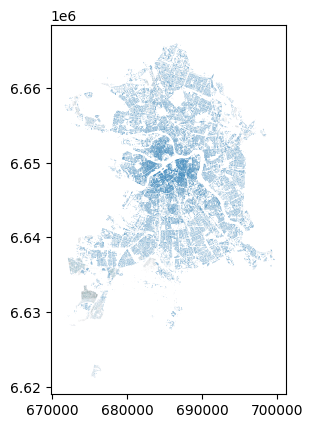

In [66]:
gpd.GeoDataFrame(
    geometry=united_geom
).plot()

In [53]:
def get_intersection_components(geometries):
    tree = STRtree(geometries)
    
    edges = []

    for i, geom in enumerate(tqdm(geometries)):
        possible_idx = tree.query(geom)

        for idx in possible_idx:
            if idx > i:
                continue
            elif geometries[idx].intersects(geom):
                edges.append((int(idx), int(i)))

    G = nx.Graph()
    G.add_edges_from(edges)

    return list(nx.connected_components(G))

In [67]:
intersection_components = get_intersection_components(united_geom)

100%|██████████| 129875/129875 [00:01<00:00, 80195.52it/s]


In [68]:
len(intersection_components)

89175

In [69]:
# разделение индексов объединения фигур A и Б на индексы конкретно для А и конкретно для Б
def decompose(lst, b_start):
    return list(filter(lambda x: x < b_start, lst)), [i - b_start for i in lst if i >= b_start]

# получить разложение компонента связности на геометрию A и геометрию Б
def get_conn_decomposition(conn, b_start, geom_a, geom_b):
    a, b = decompose(list(conn), b_start)
    return geom_a[a], geom_b[b]

def plot_geom(geom):
    gpd.GeoDataFrame(
        geometry=geom
    ).plot()

# нарисовать общую компоненту связности по отдельности для геометрий А и Б (на разных картинках)
def plot_decomposition(conn, b_start, geom_a, geom_b):
    g_a, g_b = get_conn_decomposition(conn, b_start, geom_a, geom_b)
    plot_geom(g_a)
    plot_geom(g_b)


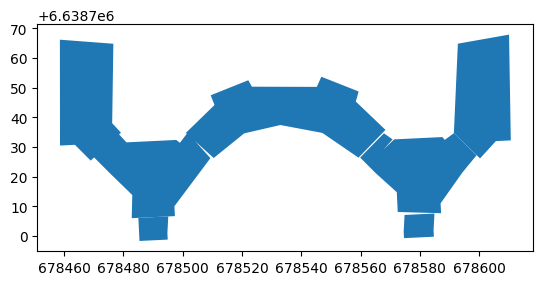

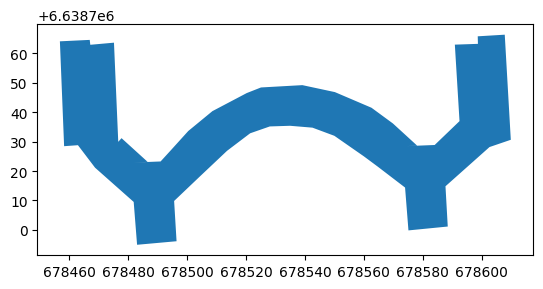

In [70]:
plot_decomposition(intersection_components[4], b_start, a_geom, b_geom)

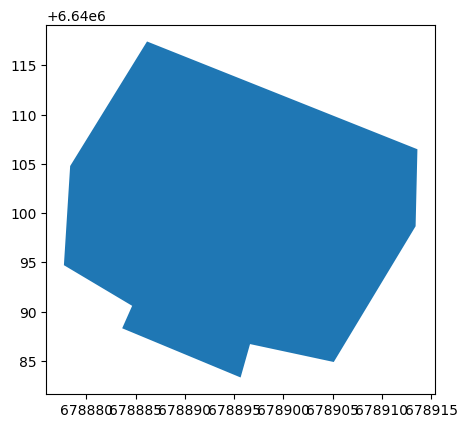

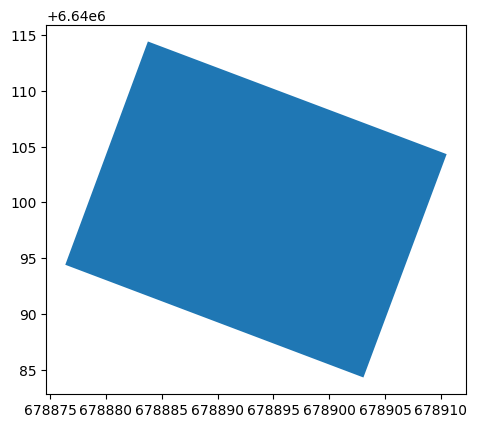

In [71]:
plot_decomposition(intersection_components[5], b_start, a_geom, b_geom)

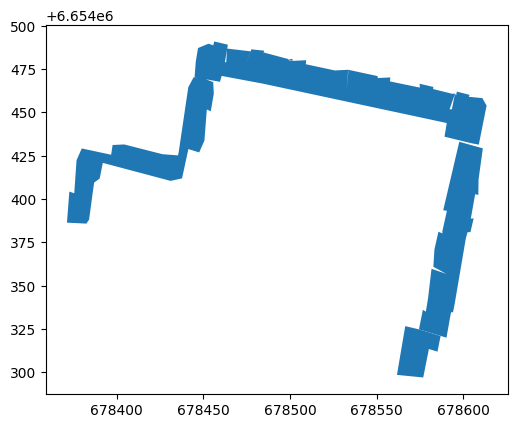

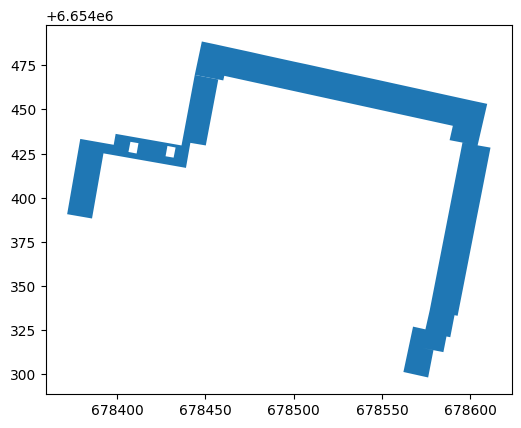

In [72]:
plot_decomposition(intersection_components[6], b_start, a_geom, b_geom)

In [87]:

component = intersection_components[6]
a_idx, b_idx = decompose(list(component), b_start)

gdf_a_part, gdf_b_part = gdf_a.loc[a_idx], gdf_b.loc[b_idx]

In [88]:
gdf_a_part.head()

,title,tags,geometry,area_sq_m,gkh_address,gkh_floor_count_min,gkh_floor_count_max,area_m2,component,is_isolated,centroid,union
6,NaN,['жилое здание'],"MULTIPOLYGON (((678901.59 6640088.051, 678882....",42.8871,NaN,NaN,NaN,42.763701,5,False,POINT (678895.0840700842 6640099.946092756),"POLYGON ((678913.4200817954 6640098.660753292,..."
19610,NaN,['жилое здание'],"POLYGON ((678073.446 6638887.07, 678073.5 6638...",37.4708,NaN,NaN,NaN,37.468762,17953,False,POINT (678077.1672788962 6638844.907846425),"POLYGON ((678089.5048758739 6638809.765154254,..."


In [89]:
gdf_b_part.head()

,subject,district,type,locality,type_street,name_street,number,letter,fraction,housing,...,stairs_numeric,avg_floor_height_numeric,height_calculated,height_numeric,geometry,area_m2,component,is_isolated,centroid,union
8230,Санкт-Петербург,Санкт-Петербург,город,Санкт-Петербург,проспект,Ленинский,53,NaN,NaN,3,...,16.0,3.0,NaN,48.0,"POLYGON ((677446.729 6640245.534, 677440.749 6...",723.8766,6902,False,POINT (677468.2635340404 6640262.969192326),"POLYGON ((677457.2007370291 6640267.004072928,..."


In [77]:
gdf_b_part.columns

Index(['subject', 'district', 'type', 'locality', 'type_street', 'name_street',
       'number', 'letter', 'fraction', 'housing', 'building',
       'purpose_of_building', 'stairs', 'avg_floor_height', 'height', 'wkt',
       'id', 'stairs_numeric', 'avg_floor_height_numeric', 'height_calculated',
       'height_numeric', 'geometry', 'area_m2', 'component', 'is_isolated',
       'centroid', 'union'],
      dtype='str')

In [83]:
gdf_b_part.height

7936    54.0
Name: height, dtype: float64